<a href="https://colab.research.google.com/github/sammygoesbrrr/Differential-Equation/blob/main/Strang_DELA_P_1_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== SCIPY NUMERICAL SOLUTIONS ===
1. Slope dy/dt of y = e^t at t = 0 : 1.000000
2. Intersection point (t, y)        : (1.000000, 2.718282)
   --> Exact point in symbols       : (1, e)
3. Difference f(1) at minimum       : 5.329071e-14



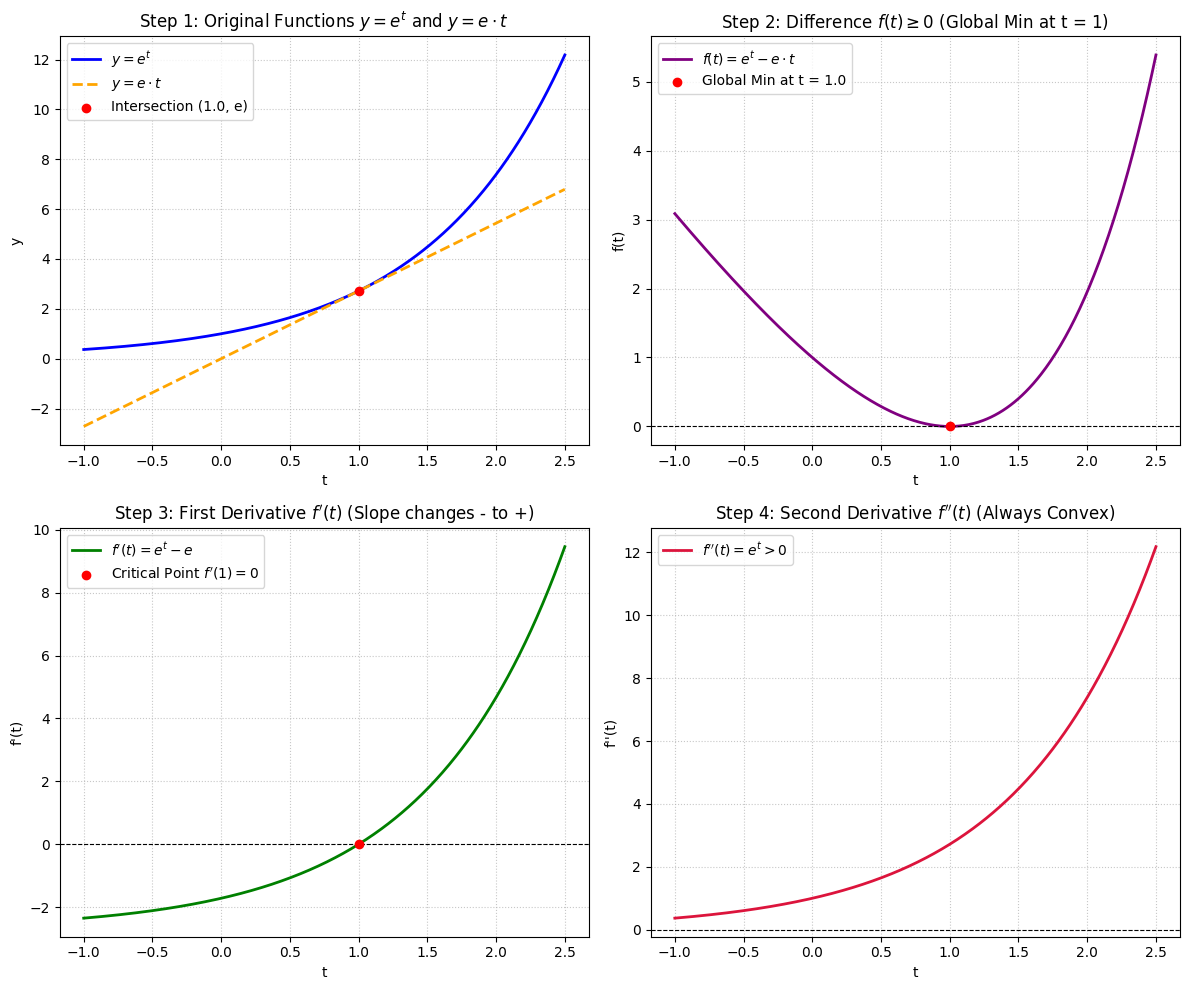

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import approx_fprime, fsolve, minimize_scalar

# 1. DEFINE MATHEMATICAL FUNCTIONS
f_exp = lambda t: np.exp(t)
f_line = lambda t: np.e * t
f_diff = lambda t: f_exp(t) - f_line(t)  # Difference f(t) = e^t - e*t
f_prime = lambda t: np.exp(t) - np.e  # f'(t) = e^t - e
f_double_prime = lambda t: np.exp(t)  # f''(t) = e^t

# =====================================================================
# 2. SOLVE THE MATH PROBLEMS USING SCIPY
# =====================================================================

# Problem 1: Find slope dy/dt of y = e^t at t = 0
slope_at_0 = approx_fprime(np.array([0.0]), lambda x: f_exp(x[0]), 1e-6)[0]

# Problem 2: Find intersection point where e^t = e*t -> f_diff(t) = 0
res_min = minimize_scalar(f_diff, bounds=(-1, 3), method="bounded")
t_intersect = res_min.x
y_intersect = f_exp(t_intersect)

# Verification using local root solver (fsolve)
t_fsolve = fsolve(f_diff, x0=0.5)[0]

print("=== SCIPY NUMERICAL SOLUTIONS ===")
print(f"1. Slope dy/dt of y = e^t at t = 0 : {slope_at_0:.6f}")
print(
    f"2. Intersection point (t, y)        : ({t_intersect:.6f}, {y_intersect:.6f})"
)
print(f"   --> Exact point in symbols       : (1, e)")
print(f"3. Difference f(1) at minimum       : {res_min.fun:.6e}")
print("===================================\n")

# =====================================================================
# 3. VISUALIZE ALL 4 CALCULUS STEPS IN ONE CANVAS
# =====================================================================

t_vals = np.linspace(-1, 2.5, 500)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- PANEL 1: Original Functions ---
axes[0, 0].plot(t_vals, f_exp(t_vals), label=r"$y = e^t$", color="blue", lw=2)
axes[0, 0].plot(
    t_vals,
    f_line(t_vals),
    label=r"$y = e \cdot t$",
    color="orange",
    linestyle="--",
    lw=2,
)
axes[0, 0].scatter(
    [t_intersect],
    [y_intersect],
    color="red",
    zorder=5,
    label=f"Intersection ({t_intersect:.1f}, e)",
)
axes[0, 0].set_title(r"Step 1: Original Functions $y = e^t$ and $y = e \cdot t$")
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("y")
axes[0, 0].grid(True, linestyle=":", alpha=0.7)
axes[0, 0].legend()

# --- PANEL 2: Difference Function f(t) ---
axes[0, 1].plot(
    t_vals,
    f_diff(t_vals),
    color="purple",
    lw=2,
    label=r"$f(t) = e^t - e \cdot t$",
)
axes[0, 1].scatter(
    [t_intersect],
    [res_min.fun],
    color="red",
    zorder=5,
    label=f"Global Min at t = {t_intersect:.1f}",
)
axes[0, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 1].set_title(r"Step 2: Difference $f(t) \geq 0$ (Global Min at t = 1)")
axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("f(t)")
axes[0, 1].grid(True, linestyle=":", alpha=0.7)
axes[0, 1].legend()

# --- PANEL 3: First Derivative f'(t) ---
axes[1, 0].plot(
    t_vals, f_prime(t_vals), color="green", lw=2, label=r"$f'(t) = e^t - e$"
)
axes[1, 0].scatter(
    [t_intersect],
    [0],
    color="red",
    zorder=5,
    label=r"Critical Point $f'(1) = 0$",
)
axes[1, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1, 0].set_title(r"Step 3: First Derivative $f'(t)$ (Slope changes - to +)")
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel("f'(t)")
axes[1, 0].grid(True, linestyle=":", alpha=0.7)
axes[1, 0].legend()

# --- PANEL 4: Second Derivative f''(t) ---
axes[1, 1].plot(
    t_vals, f_double_prime(t_vals), color="crimson", lw=2, label=r"$f''(t) = e^t > 0$"
)
axes[1, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1, 1].set_title(r"Step 4: Second Derivative $f''(t)$ (Always Convex)")
axes[1, 1].set_xlabel("t")
axes[1, 1].set_ylabel("f''(t)")
axes[1, 1].grid(True, linestyle=":", alpha=0.7)
axes[1, 1].legend()

plt.tight_layout()
plt.show()